## `Tele-communication Customer Churn Segementation `

### `Unsupervised Learning`

Predictive model that classify unlabelled data based on the nearest distance or uniform values

### `Importing Libraries`

In [57]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as  sns; sns.set_theme()

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

import warnings
warnings.filterwarnings('ignore')

### `Importing Churn Dataset`

In [58]:
churn = pd.read_csv('../Dataset/Telco-Customer-Churn.csv')

churn.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### `Data Preprocessing`

In [59]:
churn['TotalCharges'] = pd.to_numeric(churn['TotalCharges'], errors='coerce')
churn['TotalCharges'] = churn['TotalCharges'].fillna(churn['TotalCharges'].median())

In [60]:
churn = churn.drop(columns=['customerID'], axis=1)

### `Features Encoding`

In [61]:
churn['gender'] = churn['gender'].map({'Male': 1, 'Female': 0})
churn['Partner'] = churn['Partner'].map({'Yes': 1, 'No': 0})
churn['Dependents'] = churn['Dependents'].map({'Yes': 1, 'No': 0})
churn['PhoneService'] = churn['PhoneService'].map({'Yes' : 1, 'No': 0})
churn['PaperlessBilling'] = churn['PaperlessBilling'].map({'Yes': 1, 'No': 0})
churn['Churn'] = churn['Churn'].map({'Yes': 1, 'No': 0})

In [62]:
churn = pd.get_dummies(churn, columns=['PaymentMethod', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract'], dtype=int, drop_first=True)

churn.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year
0,0,0,1,0,1,0,1,29.85,29.85,0,...,0,0,0,0,0,0,0,0,0,0
1,1,0,0,0,34,1,0,56.95,1889.50,0,...,0,1,0,0,0,0,0,0,1,0
2,1,0,0,0,2,1,1,53.85,108.15,1,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,45,0,0,42.30,1840.75,0,...,0,1,0,1,0,0,0,0,1,0
4,0,0,0,0,2,1,1,70.70,151.65,1,...,0,0,0,0,0,0,0,0,0,0


#### `Feature Scaling`

In [63]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(churn.drop(columns=['Churn']))

#### `Finding optimal number of cluster (k)`

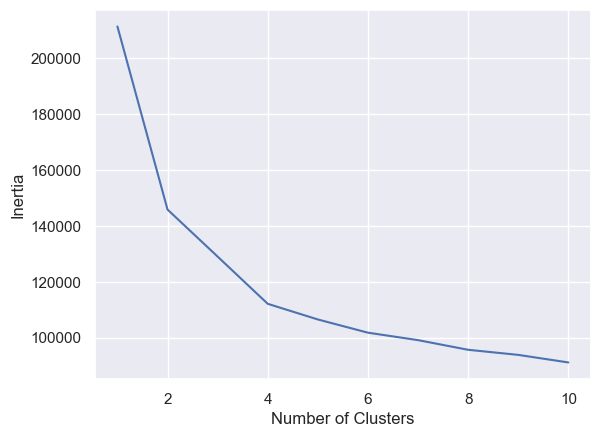

In [64]:
inertia = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(range(1, 11), inertia)
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.show()

#### `Training Model`

In [65]:
kmeans = KMeans(n_clusters=4, random_state=42)
cluster = kmeans.fit_predict(X_scaled)

In [66]:
churn['Cluster'] = cluster

In [67]:
churn.groupby('Cluster').mean()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year
Cluster,,,,,,,,,,,,,,,,,,,,,
0,0.514663,0.152493,0.456012,0.302053,31.737537,0.0,0.567449,42.028592,1500.131818,0.249267,...,0.0,0.447214,0.0,0.423754,0.0,0.417889,0.0,0.436950,0.212610,0.236070
1,0.502742,0.215356,0.313711,0.175137,15.538208,1.0,0.703108,73.985356,1172.303007,0.466910,...,0.0,0.225960,0.0,0.184644,0.0,0.325046,0.0,0.327605,0.079342,0.009141
2,0.500000,0.189048,0.711905,0.372381,55.825238,1.0,0.673810,91.874429,5153.658357,0.147143,...,0.0,0.713810,0.0,0.595238,0.0,0.730000,0.0,0.732381,0.355714,0.414762
3,0.510485,0.034076,0.483617,0.421363,30.547182,1.0,0.292267,21.079194,668.099443,0.074050,...,1.0,0.000000,1.0,0.000000,1.0,0.000000,1.0,0.000000,0.238532,0.418087


In [68]:
pd.crosstab(churn['Cluster'], churn['Churn'], normalize='index')

Churn,0,1
Cluster,,
0,0.750733,0.249267
1,0.533090,0.466910
2,0.852857,0.147143
3,0.925950,0.074050


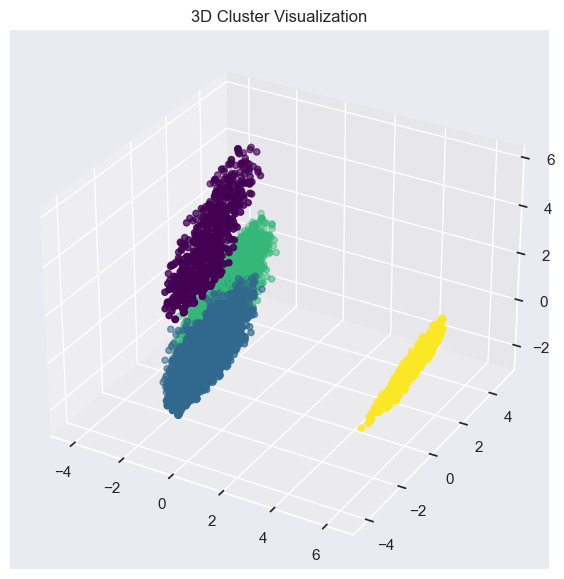

In [69]:
from mpl_toolkits.mplot3d import Axes3D

pca = PCA(n_components=3)
X_pca3 = pca.fit_transform(X_scaled)

fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(X_pca3[:,0], X_pca3[:,1], X_pca3[:,2], c=churn['Cluster'], cmap='viridis')

ax.set_title('3D Cluster Visualization')
plt.show()

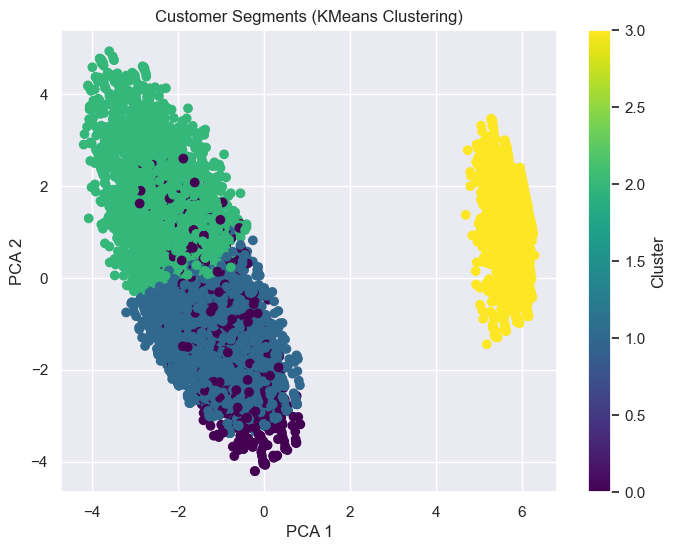

In [70]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Reduce to 2D
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Plot clusters
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=churn['Cluster'], cmap='viridis')

plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.title('Customer Segments (KMeans Clustering)')
plt.colorbar(label='Cluster')
plt.show()

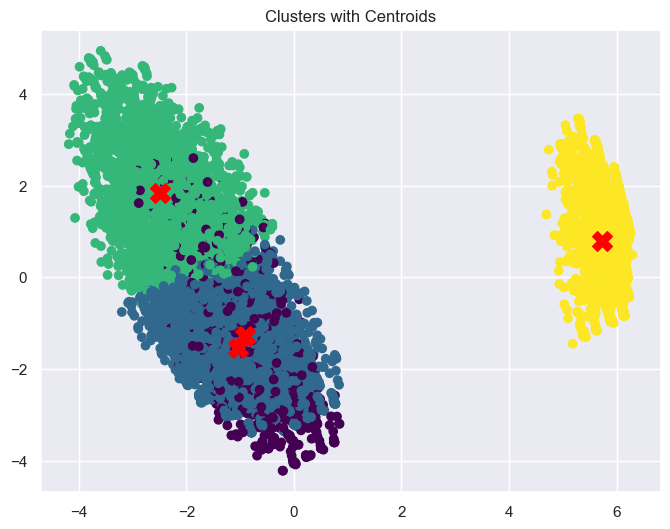

In [71]:
centers = pca.transform(kmeans.cluster_centers_)

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=churn['Cluster'], cmap='viridis')
plt.scatter(centers[:, 0], centers[:, 1], c='red', s=200, marker='X')

plt.title('Clusters with Centroids')
plt.show()